# Flow depth map with PyGMT
Plots the maximum inundation depth for one event from a `*_flowdepth.nc` file over the shaded bathymetry/topography, with the zero (coastline) contour and the flood extent outline.

In [10]:
import numpy as np
import xarray as xr
import pygmt

In [13]:
# Inputs
base_dir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami'
reg = 'CT'  # CT or SR
bathy_file = f'{base_dir}/data/processed/{reg}_defbathy.nc'  # variables: x, y, z
depth_file = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/BS_4-8_manning003_extreme_ts/E00979N4372E01586N3827-BS-M809_E01517N3827_D010_S157D70R090_A006995_S075/grid3-catania_flowdepth.nc'  # max flow depth over the simulation, z(lat, lon)
depth_var = 'z'               # variable name in depth_file
min_depth = 0.01               # m, depths below this are not drawn

cpt_bathy = f'{base_dir}/scripts/JGR/plots/extra/bathy_error.cpt'

# Panel settings (CT is tall, SR is wide)
if reg == 'CT':
    proj, pos, font = 'M7c', 'TL', '18p,Helvetica-Bold,black'
    offset = '0.15/-0.1'
else:
    proj, pos, font = 'M18c', 'BL', '14p,Helvetica-Bold,black'
    offset = '0.15/0.1'

In [14]:
grid = xr.open_dataset(bathy_file)
ds = xr.open_dataset(depth_file)
da = ds[depth_var]

# Flatten the 2D depth grid into lon/lat/depth points, dropping dry cells
xname, yname = da.dims[-1], da.dims[-2]
lon2d, lat2d = np.meshgrid(da[xname].values, da[yname].values)
depth = da.values.astype(float)
wet = np.isfinite(depth) & (depth >= min_depth)
lon, lat, dep = lon2d[wet], lat2d[wet], depth[wet]

xmin, xmax = float(grid['x'].min()), float(grid['x'].max())
ymin, ymax = float(grid['y'].min()), float(grid['y'].max())
region = [xmin, xmax, ymin, ymax]
print(f'{wet.sum()} wet points, max depth {dep.max():.2f} m')

177281 wet points, max depth 8.49 m


xyz2grd [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
xyz2grd [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
xyz2grd (gmtapi_init_grdheader): Please select compatible -R and -I values


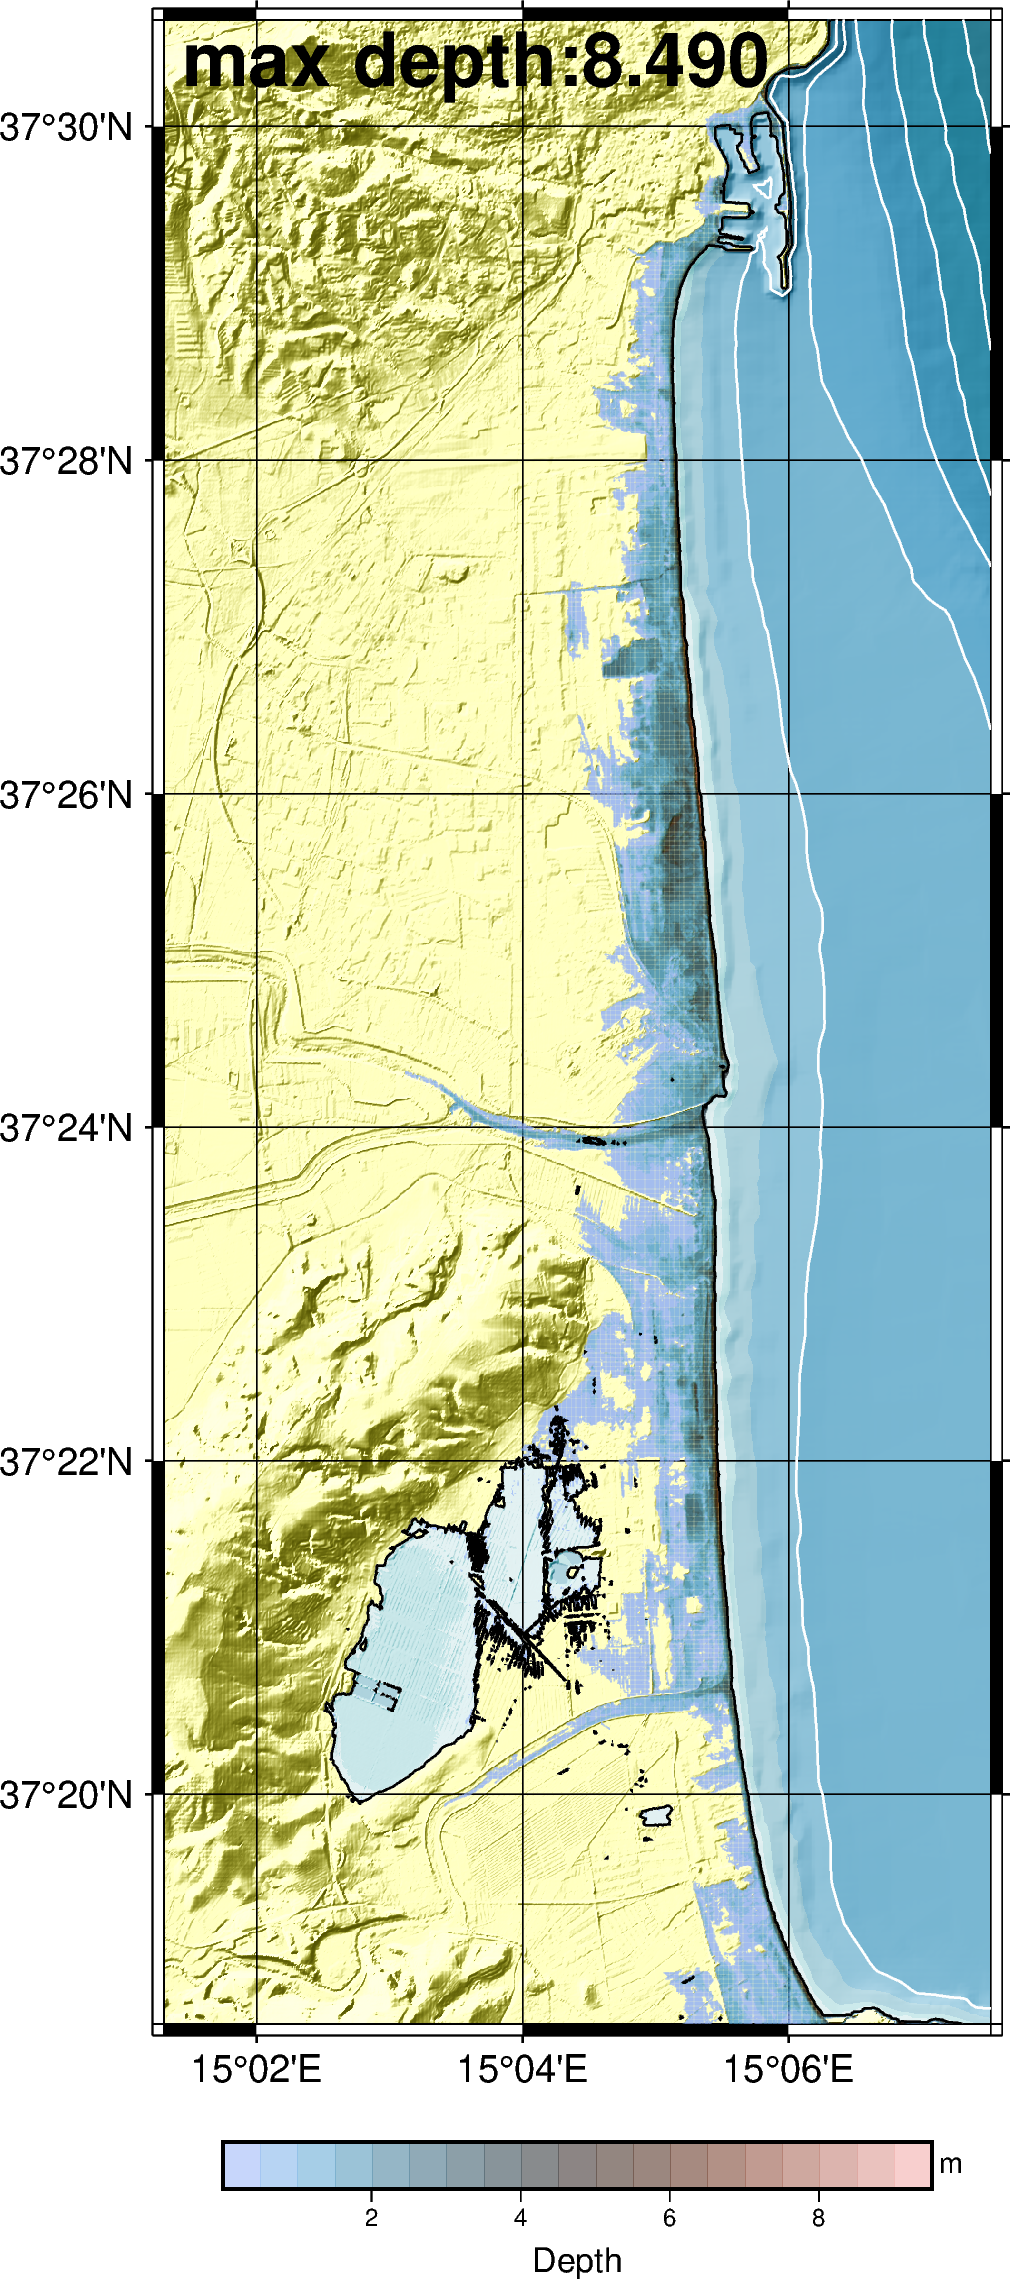

In [15]:
# Flood extent grid (cm integer, 1 cm threshold) for the red outline
extent = pygmt.xyz2grd(x=lon, y=lat, z=(dep * 100).astype(int), spacing='1s', region=region)

fig = pygmt.Figure()

# Basemap: shaded bathymetry/topography with bathymetric contours
pygmt.makecpt(cmap=cpt_bathy, continuous=False)
fig.grdimage(grid['z'], cmap=True, shading=True, region=region, projection=proj, frame=['ag'])
fig.grdcontour(grid['z'], levels=10, pen='0.5p,white', limit=[-100, 0], projection=proj)

# Flow depth
pygmt.makecpt(cmap='berlin', series=[min_depth, 10, 0.5], transparency=50, background=True)
fig.plot(x=lon, y=lat, fill=dep, style='s0.01c', cmap=True, projection=proj)

# Coastline and flood extent
fig.grdcontour(grid['z'], levels=1, limit=[-0.5, 0.5], annotation=False, pen='0.5p,black', projection=proj)
fig.grdcontour(extent, levels=[1], limit=[0, 10], cut=10, pen='0.75p,red', projection=proj)

fig.text(position=pos, text=f'max depth:{dep.max():.3f}', font=font, offset=offset, projection=proj)
fig.colorbar(cmap=True, position='JBC+o0/1c+w6c/0.4c+h', frame=['a2', 'x+lDepth', 'y+lm'])
fig.show()